In [1]:
import json
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFECV, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import PowerTransformer
from defenders.multi_turn.integrated.inference.transforms import TRANSFORMS

os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("config", exist_ok=True)

In [51]:
def conversation_split(df):
    all_conv_ids = df["conv_id"].unique()
    train_val_ids, test_ids = train_test_split(all_conv_ids, test_size=0.2, random_state=42, shuffle=True, stratify=df.groupby("conv_id")["label"].max())
    train_ids, val_ids = train_test_split(train_val_ids, test_size=0.25, random_state=42, shuffle=True, stratify=df[df["conv_id"].isin(train_val_ids)].groupby("conv_id")["label"].max())

    train_df = df[df["conv_id"].isin(train_ids)].reset_index(drop=True)
    val_df = df[df["conv_id"].isin(val_ids)].reset_index(drop=True)
    test_df = df[df["conv_id"].isin(test_ids)].reset_index(drop=True)

    return {"train": train_df, "val": val_df, "test": test_df}


def remove_multicollinear(X_train, y_train, threshold):
    corr_df = X_train.copy()
    corr_df["target"] = y_train.values
    corr_matrix = corr_df.corr()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_remove = set()
    for col in upper.columns:
        if col == "target":
            continue
        highly_correlated = upper.index[abs(upper[col]) > threshold].tolist()
        for other_col in highly_correlated:
            if other_col == "target" or other_col in to_remove or col in to_remove:
                continue
            corr_col = abs(corr_matrix.loc[col, "target"])
            corr_other_col = abs(corr_matrix.loc[other_col, "target"])
            if corr_col >= corr_other_col:
                to_remove.add(other_col)
            else:
                to_remove.add(col)

    cols_to_keep = [c for c in X_train.columns if c not in to_remove]
    return cols_to_keep


def save_split(X, meta, y, path):
    out = X.copy()
    out["conv_id"] = meta["conv_id"].values
    out["turn_id"] = meta["turn_id"].values
    out["label"] = y.values
    out.to_csv(path, index=False)
    print(f"Saved {path}  shape={out.shape}")



def _apply_transform(series, transform):
    if transform == "log1p":
        return np.log1p(np.maximum(series, 0))

    if transform == "square":
        return np.square(series)

    if transform == "binarize":
        return (series > 0).astype(float)

    if transform == "yeo-johnson":
        pt = PowerTransformer(method="yeo-johnson", standardize=False)
        return pt.fit_transform(
            np.asarray(series).reshape(-1, 1)
        ).flatten()

    return series


def apply_transform(df):
    df = df.copy()
    for feature, transform in TRANSFORMS.items():
        if feature not in df.columns:
            continue
        df[f"{feature}"] = _apply_transform(df[feature], transform)
    return df

In [ ]:
df = pd.read_csv("../data/total/features_before_selection(6).csv")

splits = conversation_split(df)
train_df = splits["train"]
val_df = splits["val"]
test_df = splits["test"]


train_df_trans = apply_transform(train_df)
val_df_trans = apply_transform(val_df)
test_df_trans = apply_transform(test_df)

feature_cols = [c for c in train_df_trans.columns if c not in ["conv_id", "turn_id", "label"]]

meta_train= train_df[["conv_id","turn_id"]]
meta_val= val_df[["conv_id","turn_id"]]
meta_test= test_df[["conv_id","turn_id"]]

X_train= train_df_trans[feature_cols]
X_val= val_df_trans[feature_cols]
X_test= test_df_trans[feature_cols]

y_train= train_df["label"]
y_val= val_df["label"]
y_test= test_df["label"]

In [53]:
corr_vals = X_train.corrwith(y_train).abs().sort_values(ascending=False)
corr_vals

prev_progressive          0.532866
progressive_risk          0.482823
drift_momentum            0.346903
drift_acceleration        0.346821
trajectory_linearity      0.346821
angular_coverage          0.346398
std_similarity            0.338904
pattern_risk_ema3         0.311718
max_similarity            0.278761
origin_drift              0.242748
persistent_drift_count    0.215491
mean_similarity           0.210258
topic_drift_score         0.210185
distance_ratio            0.210112
min_similarity            0.205485
pattern_risk              0.174273
max_threat_so_far         0.166797
max_toxicity_so_far       0.149053
interaction_risk_ema3     0.120500
mean_risk_so_far          0.111434
interaction_risk          0.108132
threat_accel              0.093925
threat_score_ema3         0.084698
toxicity_score_ema3       0.083701
threat_score              0.078610
toxicity_score            0.076543
early_high_risk           0.075804
late_risk_increase        0.074684
toxicity_accel      

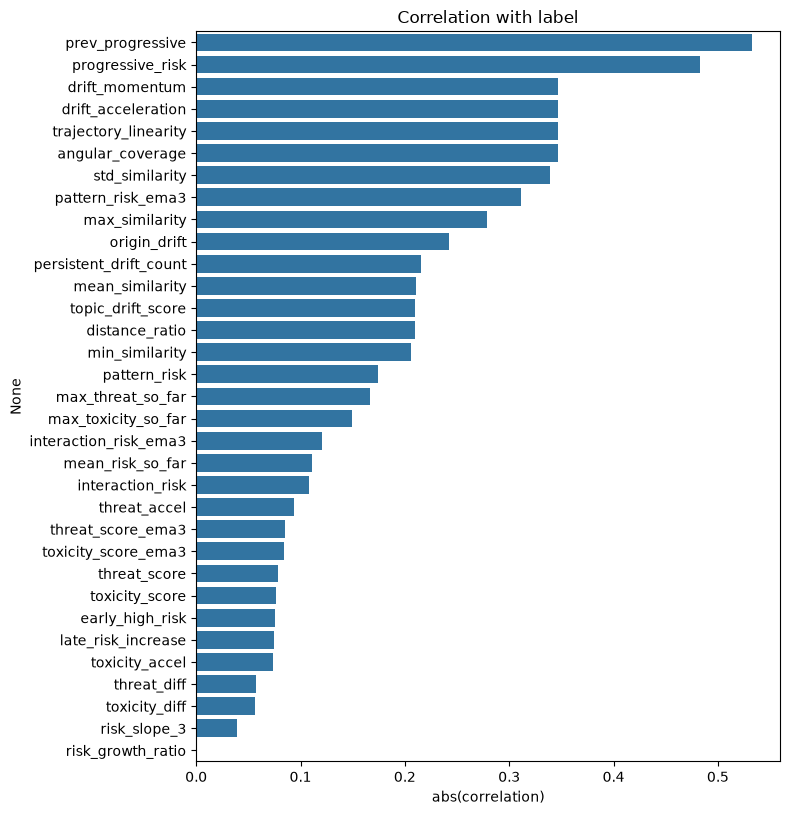

In [54]:
plt.figure(figsize=(8, max(4, len(corr_vals) * 0.25)))
sns.barplot(x=corr_vals.values, y=corr_vals.index)
plt.title("Correlation with label")
plt.xlabel("abs(correlation)")
plt.tight_layout()
plt.show()

In [ ]:
var_sel = VarianceThreshold(threshold=0.0001)
var_sel.fit(X_train)
var_cols = X_train.columns[var_sel.get_support()].tolist()
X_train_var = pd.DataFrame(var_sel.transform(X_train), columns=var_cols)
X_val_var = pd.DataFrame(var_sel.transform(X_val), columns=var_cols)
X_test_var = pd.DataFrame(var_sel.transform(X_test), columns=var_cols)
print(f"After variance filter: {len(var_cols)}")
var_cols

In [57]:
corr_vals = X_train.corrwith(y_train,method="spearman").abs().sort_values(ascending=False)
corr_vals

prev_progressive          0.482830
progressive_risk          0.444401
max_similarity            0.386693
std_similarity            0.348336
drift_momentum            0.346903
drift_acceleration        0.346821
trajectory_linearity      0.346821
angular_coverage          0.346398
pattern_risk_ema3         0.317397
toxicity_accel            0.242922
origin_drift              0.234087
persistent_drift_count    0.229594
max_toxicity_so_far       0.222532
threat_accel              0.219007
toxicity_diff             0.217183
mean_similarity           0.210258
topic_drift_score         0.210185
distance_ratio            0.210112
min_similarity            0.205485
max_threat_so_far         0.201683
threat_diff               0.200834
toxicity_score_ema3       0.169828
pattern_risk              0.161832
mean_risk_so_far          0.157500
risk_slope_3              0.153955
interaction_risk_ema3     0.153165
threat_score_ema3         0.132280
interaction_risk          0.126829
toxicity_score      

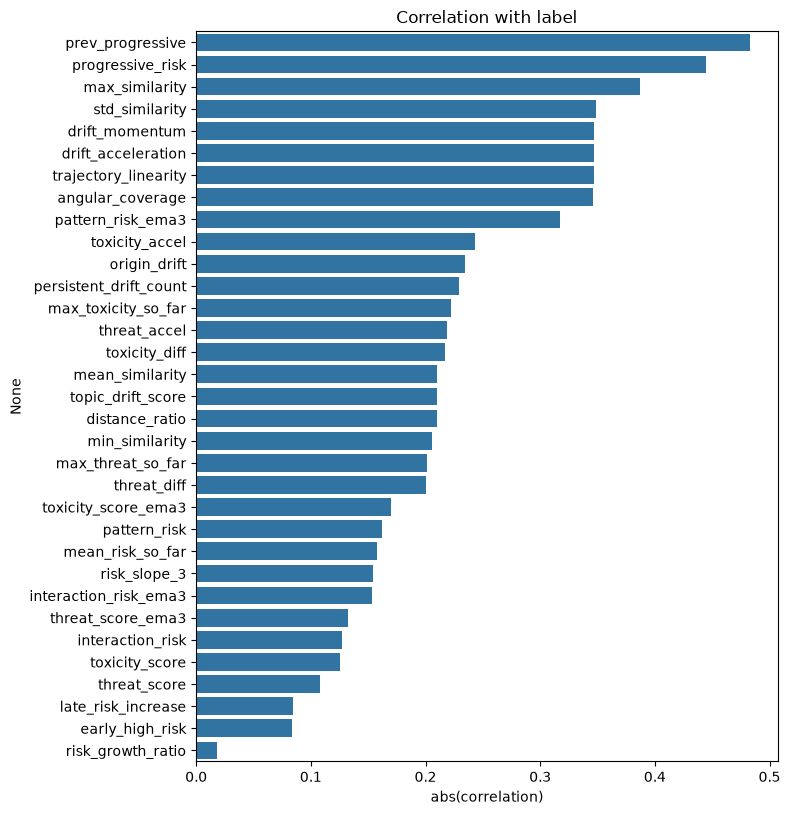

In [58]:
plt.figure(figsize=(8, max(4, len(corr_vals) * 0.25)))
sns.barplot(x=corr_vals.values, y=corr_vals.index)
plt.title("Correlation with label")
plt.xlabel("abs(correlation)")
plt.tight_layout()
plt.show()

In [ ]:
corr_cols = corr_vals[corr_vals > 0.005].index.tolist()
X_train_corr = X_train_var[corr_cols]
X_val_corr = X_val_var[corr_cols]
X_test_corr = X_test_var[corr_cols]
print(f"After correlation filter: {len(corr_cols)}")

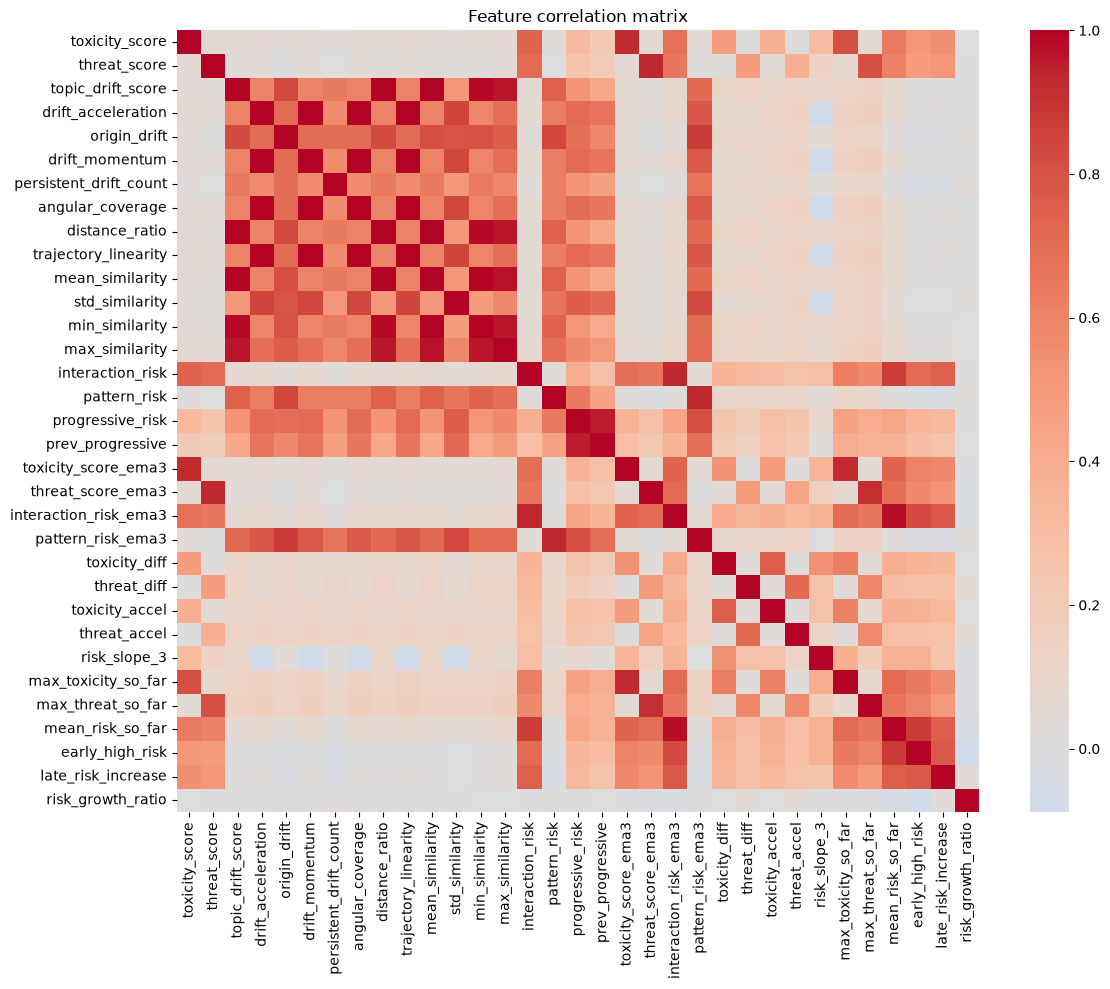

In [60]:
corr_matrix = X_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [61]:
mc_cols = remove_multicollinear(X_train, y_train, 0.9)
X_train_final = X_train[mc_cols]
X_val_final = X_val[mc_cols]
X_test_final = X_test[mc_cols]
print(f"After multicollinearity: {len(mc_cols)}")
mc_cols

After multicollinearity: 18


['origin_drift',
 'drift_momentum',
 'persistent_drift_count',
 'std_similarity',
 'max_similarity',
 'prev_progressive',
 'interaction_risk_ema3',
 'pattern_risk_ema3',
 'toxicity_diff',
 'threat_diff',
 'toxicity_accel',
 'threat_accel',
 'risk_slope_3',
 'max_toxicity_so_far',
 'max_threat_so_far',
 'early_high_risk',
 'late_risk_increase',
 'risk_growth_ratio']

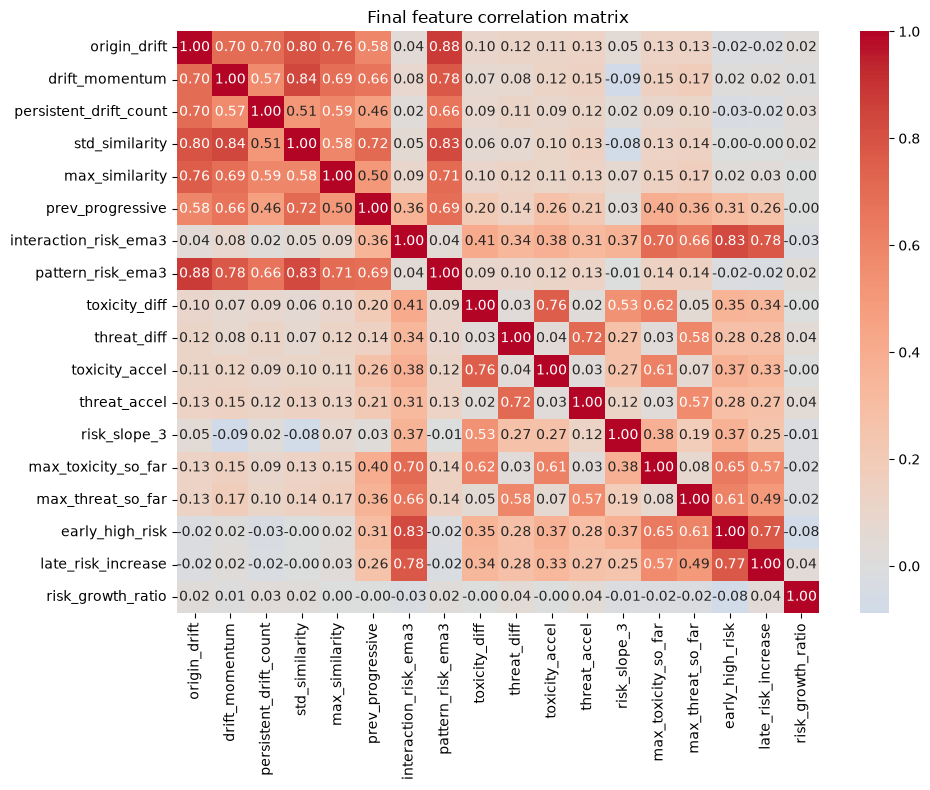

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train_final.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Final feature correlation matrix")
plt.tight_layout()
plt.show()

In [63]:
scaler = RobustScaler()
X_train_final = pd.DataFrame(scaler.fit_transform(X_train_final), columns=X_train_final.columns)
X_val_final = pd.DataFrame(scaler.transform(X_val_final), columns=X_val_final.columns)
X_test_final = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns)
joblib.dump(scaler, "../models/scaler(6).pkl")
X_train_final.head()

,origin_drift,drift_momentum,persistent_drift_count,std_similarity,max_similarity,prev_progressive,interaction_risk_ema3,pattern_risk_ema3,toxicity_diff,threat_diff,toxicity_accel,threat_accel,risk_slope_3,max_toxicity_so_far,max_threat_so_far,early_high_risk,late_risk_increase,risk_growth_ratio
0,-1.342565,-1.0,-0.630930,-0.557276,-3.282211,-0.343347,-0.221530,-0.982146,-0.007846,-0.023199,-0.008654,-0.025492,-0.025361,-0.086137,-0.200871,-0.315999,-0.312291,0.739779
1,-0.005320,-1.0,0.000000,-0.557276,-0.447156,-0.337271,-0.250529,-0.233093,-0.004262,-0.000299,-0.007496,-0.016954,-0.006088,-0.086137,-0.200871,-0.315999,-0.312291,0.739779
2,0.638550,0.0,0.369070,0.306272,-0.447156,-0.003498,-0.273522,0.102516,-0.005107,-0.022322,-0.008635,-0.019969,-0.017374,-0.086137,-0.200871,-0.315999,-0.312291,0.739779
3,0.906540,0.0,0.630930,0.606330,-0.240826,0.339797,-0.283230,0.373226,-0.007235,-0.023197,-0.006735,-0.025139,-0.022149,-0.086137,-0.200871,-0.315999,-0.312291,0.739779
4,0.836720,0.0,0.834044,0.486223,-0.240826,0.752221,-0.282138,0.766055,0.000398,-0.023199,-0.007243,-0.025491,-0.025360,-0.085042,-0.200871,-0.315999,-0.312291,0.739779


In [64]:

save_split(X_train_final, meta_train, y_train, "../data/processed/train(6).csv")
save_split(X_val_final, meta_val, y_val, "../data/processed/validation(6).csv")
save_split(X_test_final, meta_test, y_test, "../data/processed/test(6).csv")

with open("../config/feature_info(6).json", "w") as f:
    json.dump({"selected_features": mc_cols, "scaler_path": "../models/scaler(6).pkl"}, f, indent=4)

print(f"\nOriginal: {len(feature_cols)}  Final: {len(mc_cols)}")

Saved ../data/processed/train(6).csv  shape=(8668, 21)
Saved ../data/processed/validation(6).csv  shape=(2844, 21)
Saved ../data/processed/test(6).csv  shape=(2872, 21)

Original: 33  Final: 18
